In [1]:
from sklearn.base import clone
from itertools import combinations
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


class SBS():
    def __init__(self, estimator, k_features, scoring=accuracy_score,
                 test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):

        X_train, X_test, y_train, y_test = \
            train_test_split(X, y, test_size=self.test_size,
                             random_state=self.random_state)

        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train,
                                 X_test, y_test, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train,
                                         X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])
        self.k_score_ = self.scores_[-1]

        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score

In [3]:
import numpy as np
import pandas as pd

df_wine = pd.read_csv('https://archive.ics.uci.edu/'
                      'ml/machine-learning-databases/wine/wine.data',
                      header=None)


df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test =\
    train_test_split(X, y,
                     test_size=0.3,
                     random_state=0,
                     stratify=y)

from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)


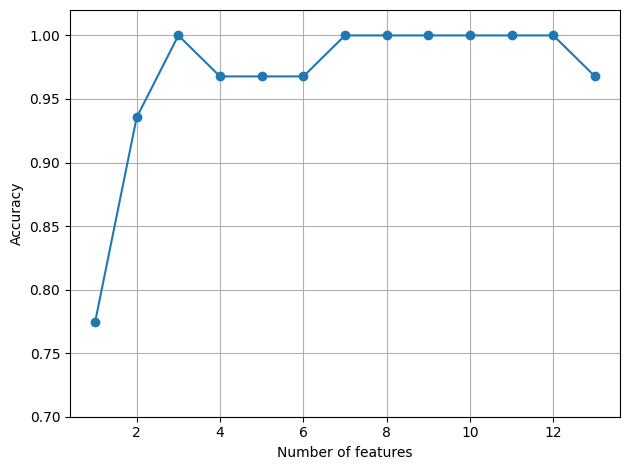

In [9]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

sbs = SBS(knn, k_features=1)
sbs.fit(X_train_std, y_train)

k_feat = [len(k) for k in sbs.subsets_]

plt.plot(k_feat, sbs.scores_, marker='o')
plt.ylim([0.7, 1.02])
plt.ylabel('Accuracy')
plt.xlabel('Number of features')
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
k3 = list(sbs.subsets_[10])
print(df_wine.columns[1:][k3])

Index(['Alcohol', 'Malic acid', 'OD280/OD315 of diluted wines'], dtype='object')


In [8]:
#정확도 비교
knn.fit(X_train_std, y_train) # 전체 특성
print('훈련 정확도:', knn.score(X_train_std, y_train))
print('테스트 정확도:', knn.score(X_test_std, y_test))

knn.fit(X_train_std[:, k3], y_train) # 선택한 특성
print('특성 선택 후 훈련 정확도:', knn.score(X_train_std[:, k3], y_train))
print('특성 선택 후 테스트 정확도:', knn.score(X_test_std[:, k3], y_test))

훈련 정확도: 0.967741935483871
테스트 정확도: 0.9629629629629629
특성 선택 후 훈련 정확도: 0.9516129032258065
특성 선택 후 테스트 정확도: 0.9259259259259259


SVM

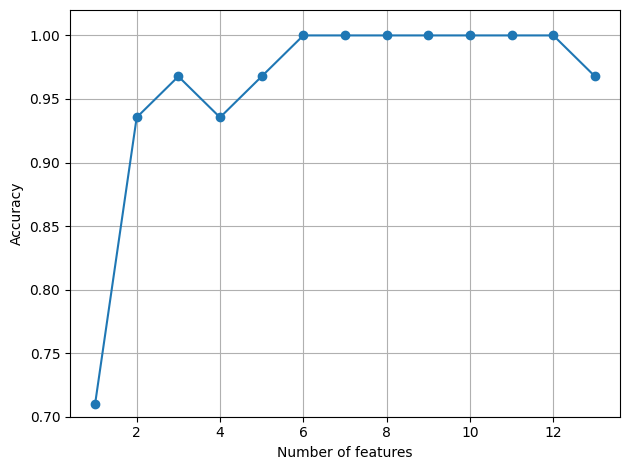

In [10]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1.0, random_state=1)

sbs_ = SBS(svm, k_features=1)
sbs_.fit(X_train_std, y_train)

k_feat_ = [len(k) for k in sbs_.subsets_]

plt.plot(k_feat, sbs_.scores_, marker='o')
plt.ylim([0.7, 1.02])
plt.ylabel('Accuracy')
plt.xlabel('Number of features')
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
k6 = list(sbs_.subsets_[7])
print(df_wine.columns[1:][k6])

Index(['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Flavanoids',
       'OD280/OD315 of diluted wines'],
      dtype='object')


In [13]:
#정확도 비교
svm.fit(X_train_std, y_train) # 전체 특성
print('훈련 정확도:', svm.score(X_train_std, y_train))
print('테스트 정확도:', svm.score(X_test_std, y_test))

svm.fit(X_train_std[:, k6], y_train) # 선택한 특성
print('특성 선택 후 훈련 정확도:', svm.score(X_train_std[:, k6], y_train))
print('특성 선택 후 테스트 정확도:', svm.score(X_test_std[:, k6], y_test))

훈련 정확도: 1.0
테스트 정확도: 1.0
특성 선택 후 훈련 정확도: 0.9838709677419355
특성 선택 후 테스트 정확도: 0.9444444444444444


 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872
 8) Magnesium                      0.031357
 9) Malic acid                     0.025648
10) Proanthocyanins                0.025570
11) Alcalinity of ash              0.022366
12) Nonflavanoid phenols           0.013354
13) Ash                            0.013279


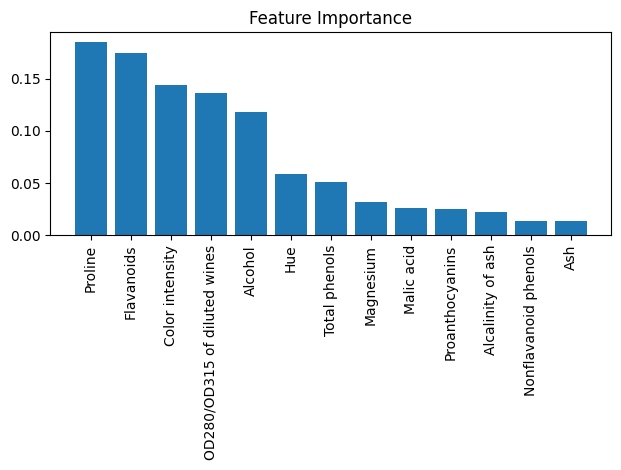

In [14]:
from sklearn.ensemble import RandomForestClassifier

feat_labels = df_wine.columns[1:]

forest = RandomForestClassifier(n_estimators=500,
                                random_state=1)

forest.fit(X_train, y_train)
importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30,
                            feat_labels[indices[f]],
                            importances[indices[f]]))

plt.title('Feature Importance')
plt.bar(range(X_train.shape[1]),
        importances[indices],
        align='center')

plt.xticks(range(X_train.shape[1]),
           feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

In [20]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(forest, threshold=0.05, prefit=True)
X_selected = sfm.transform(X_train)
print('이 임계 조건을 만족하는 샘플의 수:',
      X_selected.shape[1])

for f in range(X_selected.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30,
                            feat_labels[indices[f]],
                            importances[indices[f]]))
    


이 임계 조건을 만족하는 샘플의 수: 7
 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872


In [23]:
forest.fit(X_train_std, y_train) # 전체 특성
print('훈련 정확도:', forest.score(X_train_std, y_train))
print('테스트 정확도:', forest.score(X_test_std, y_test))

훈련 정확도: 1.0
테스트 정확도: 1.0


In [ ]:
forest_selected = RandomForestClassifier(n_estimators=500,
                                random_state=1)

# 선택된 특성으로 훈련
forest_selected.fit(sfm.transform(X_train_std), y_train)

# 정확도 평가
print('훈련 정확도:', forest_selected.score(sfm.transform(X_train_std), y_train))
print('테스트 정확도:', forest_selected.score(sfm.transform(X_test_std), y_test))

훈련 정확도: 1.0
테스트 정확도: 1.0


: 